<a href="https://colab.research.google.com/github/gowtham7019744655/student/blob/main/credit_card_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

project 3 credit card fraud detection

In [ ]:
# install the required libraries
%pip install -q numpy pandas matplotlib seaborn scikit-learn

In [ ]:
# importing the dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    average_precision_score,
)

In [ ]:
# configurations
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")

RANDOM_STATE = 42

2. load data

In [ ]:
df = pd.read_csv("creditcard.csv", delimiter=";")

3. exploratory data analysis

In [ ]:
df.shape

(25838, 1)

In [ ]:
df.head()

,"Time,""V1"",""V2"",""V3"",""V4"",""V5"",""V6"",""V7"",""V8"",""V9"",""V10"",""V11"",""V12"",""V13"",""V14"",""V15"",""V16"",""V17"",""V18"",""V19"",""V20"",""V21"",""V22"",""V23"",""V24"",""V25"",""V26"",""V27"",""V28"",""Amount"",""Class"""
0,"0,-1.3598071336738,-0.0727811733098497,2.53634..."
1,"0,1.19185711131486,0.26615071205963,0.16648011..."
2,"1,-1.35835406159823,-1.34016307473609,1.773209..."
3,"1,-0.966271711572087,-0.185226008082898,1.7929..."
4,"2,-1.15823309349523,0.877736754848451,1.548717..."


class:
- 0-> non-fraud

- 1-> fraud

In [ ]:
# basic overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25838 entries, 0 to 25837
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                Non-Null Count  Dtype 
---  ------                                                                                                                                                                                --------------  ----- 
 0   Time,"V1","V2","V3","V4","V5","V6","V7","V8","V9","V10","V11","V12","V13","V14","V15","V16","V17","V18","V19","V20","V21","V22","V23","V24","V25","V26","V27","V28","Amount","Class"  25838 non-null  object
dtypes: object(1)
memory usage: 202.0+ KB


In [ ]:
# missing values
df.isna().sum().sort_values(ascending=False)

,0
"Time,""V1"",""V2"",""V3"",""V4"",""V5"",""V6"",""V7"",""V8"",""V9"",""V10"",""V11"",""V12"",""V13"",""V14"",""V15"",""V16"",""V17"",""V18"",""V19"",""V20"",""V21"",""V22"",""V23"",""V24"",""V25"",""V26"",""V27"",""V28"",""Amount"",""Class""",0


In [ ]:
# quick checks for encoded missing values
for col in df.columns:
    print(df[col].value_counts().head(10))

Time,"V1","V2","V3","V4","V5","V6","V7","V8","V9","V10","V11","V12","V13","V14","V15","V16","V17","V18","V19","V20","V21","V22","V23","V24","V25","V26","V27","V28","Amount","Class"
31964,1.20275440465555,0.395071559663373,0.233037469781092,1.23724305093763,-0.0123607649089951,-0.508523744004067,0.279064468154986,-0.146586687414609,-0.36200251281504,0.135150189188256,1.23175598968339,1.54980981885719,0.82027129955438,0.239400884288424,-0.824368117158761,-0.228037149728663,-0.423157624300378,-0.0697215044463303,0.154798510974174,-0.0946516798986864,0.0267816614032285,0.258715955572025,-0.169719058509858,0.386205346174153,0.845610075204691,-0.281712027705658,0.0125726340640602,0.00545701312619017,1,"0"          4
24646,1.10082826580664,0.115819157849071,1.53903071360819,1.64340475512462,-0.75378102626807,0.227847022508428,-0.629308180509322,0.085985816336731,2.11690122969103,-0.70514070652057,0.689060692020201,-1.19230218268929,2.47971313958199,0.819952754894643,-1.03831749734175,-0.66781

In [ ]:
# duplicates
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
print("Number of duplicate rows:", num_duplicates)

# (optional) drop duplicates if present
#df = df.drop_duplicates()
#print("Shape after dropping duplicates:", df.shape)


Number of duplicate rows: 100


In [ ]:
# Re-loading with correct delimiter to fix the KeyError
df = pd.read_csv("creditcard.csv", delimiter=",")

# target distribution
print(df["Class"].value_counts())
print("-"*50)
print(df["Class"].value_counts(normalize=True) * 100)

Class
0.000    73198
1.000      178
Name: count, dtype: int64
--------------------------------------------------
Class
0.000   99.757
1.000    0.243
Name: proportion, dtype: float64


note: data is highly imbalanced

In [ ]:
# imbalance ratio
n_fraud = (df["Class"] == 1).sum()
n_nonfraud = (df["Class"] == 0).sum()
print(f"Fraud transactions: {n_fraud}")
print(f"Non-fraud transactions: {n_nonfraud}")
print("Imbalance ratio (non-fraud : fraud) =", round(n_nonfraud / max(n_fraud, 1), 2))

Fraud transactions: 178
Non-fraud transactions: 73198
Imbalance ratio (non-fraud : fraud) = 411.22


inference: 1 fraud transaction for every 411.22 non-fraud transactions.

In [ ]:
# descriptive stats for key columns
df[["Time", "Amount"]].describe()

,Time,Amount
count,73377.000,73376.000
mean,35585.574,97.320
std,14672.723,270.210
min,0.000,0.000
25%,29408.000,7.680
50%,38645.000,26.625
75%,46739.000,88.970
max,55107.000,19656.530


In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,73377.000,73377.000,73377.000,73377.000,73377.000,73377.000,73377.000,73377.000,73377.000,73377.000,73377.000,73377.000,73377.000,73377.000,73377.000,73377.000,73377.000,73377.000,73377.000,73377.000,73377.000,73377.000,73377.000,73377.000,73377.000,73377.000,73376.000,73376.000,73376.000,73376.000,73376.000
mean,35585.574,-0.253,-0.027,0.679,0.168,-0.272,0.098,-0.114,0.056,0.010,-0.035,0.296,-0.165,0.065,0.098,0.160,-0.007,0.081,-0.096,-0.025,0.045,-0.029,-0.106,-0.039,0.006,0.135,0.024,0.002,0.003,97.320,0.002
std,14672.723,1.881,1.665,1.409,1.372,1.388,1.305,1.252,1.235,1.156,1.088,1.087,1.206,1.072,1.025,0.937,0.919,1.006,0.859,0.818,0.758,0.738,0.637,0.622,0.596,0.440,0.498,0.387,0.325,270.210,0.049
min,0.000,-56.408,-72.716,-33.681,-5.173,-42.148,-26.161,-31.765,-73.217,-9.284,-18.271,-4.050,-17.769,-5.792,-19.214,-4.153,-13.563,-25.163,-9.499,-7.214,-15.806,-34.830,-10.933,-26.751,-2.837,-7.496,-2.534,-9.391,-9.618,0.000,0.000
25%,29408.000,-1.013,-0.595,0.191,-0.725,-0.890,-0.639,-0.604,-0.142,-0.676,-0.509,-0.494,-0.617,-0.648,-0.323,-0.394,-0.487,-0.387,-0.572,-0.520,-0.168,-0.226,-0.525,-0.179,-0.325,-0.128,-0.328,-0.063,-0.006,7.680,0.000
50%,38645.000,-0.247,0.072,0.768,0.187,-0.305,-0.152,-0.074,0.068,-0.076,-0.097,0.234,0.065,0.033,0.099,0.266,0.063,0.022,-0.086,-0.030,-0.024,-0.060,-0.080,-0.051,0.062,0.173,-0.075,0.009,0.023,26.625,0.000
75%,46739.000,1.153,0.726,1.400,1.052,0.265,0.492,0.420,0.347,0.656,0.439,1.104,0.597,0.759,0.542,0.835,0.546,0.490,0.396,0.482,0.171,0.116,0.309,0.080,0.404,0.422,0.304,0.082,0.076,88.970,0.000
max,55107.000,1.960,18.902,4.226,16.716,34.802,22.529,36.677,20.007,10.393,13.198,12.019,7.848,4.465,10.527,5.785,6.099,9.254,5.041,5.228,39.421,22.615,10.503,17.298,4.014,5.525,3.517,11.136,33.848,19656.530,1.000


data visualization

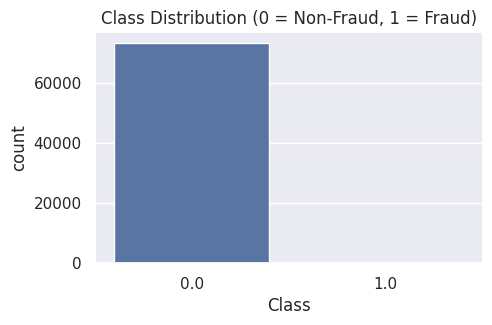

In [ ]:
# visualize class imbalance
plt.figure(figsize=(5, 3))
sns.countplot(x="Class", data=df)
plt.title("Class Distribution (0 = Non-Fraud, 1 = Fraud)")
plt.show()

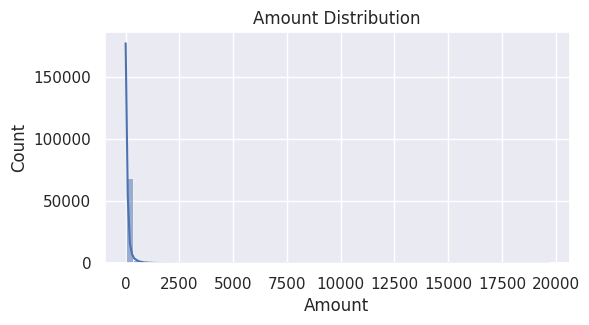

In [ ]:
# Amount distribution (raw)
plt.figure(figsize=(6, 3))
sns.histplot(df["Amount"], bins=60, kde=True)
plt.title("Amount Distribution")
plt.show()

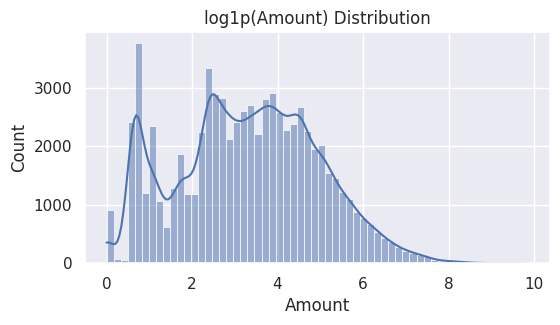

In [ ]:
# Amount distribution (raw + log1p)
plt.figure(figsize=(6, 3))
sns.histplot(np.log1p(df["Amount"]), bins=60, kde=True)
plt.title("log1p(Amount) Distribution")
plt.show()

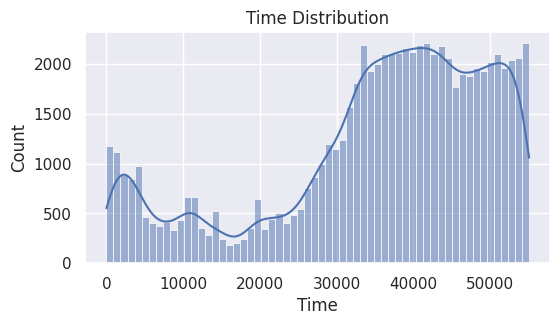

In [ ]:
# Time distribution
plt.figure(figsize=(6, 3))
sns.histplot(df["Time"], bins=60, kde=True)
plt.title("Time Distribution")
plt.show()

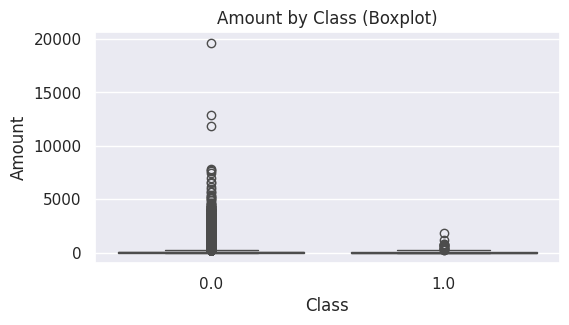

In [ ]:
# Amount by class (helps intuition)
plt.figure(figsize=(6, 3))
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Amount by Class (Boxplot)")
plt.show()

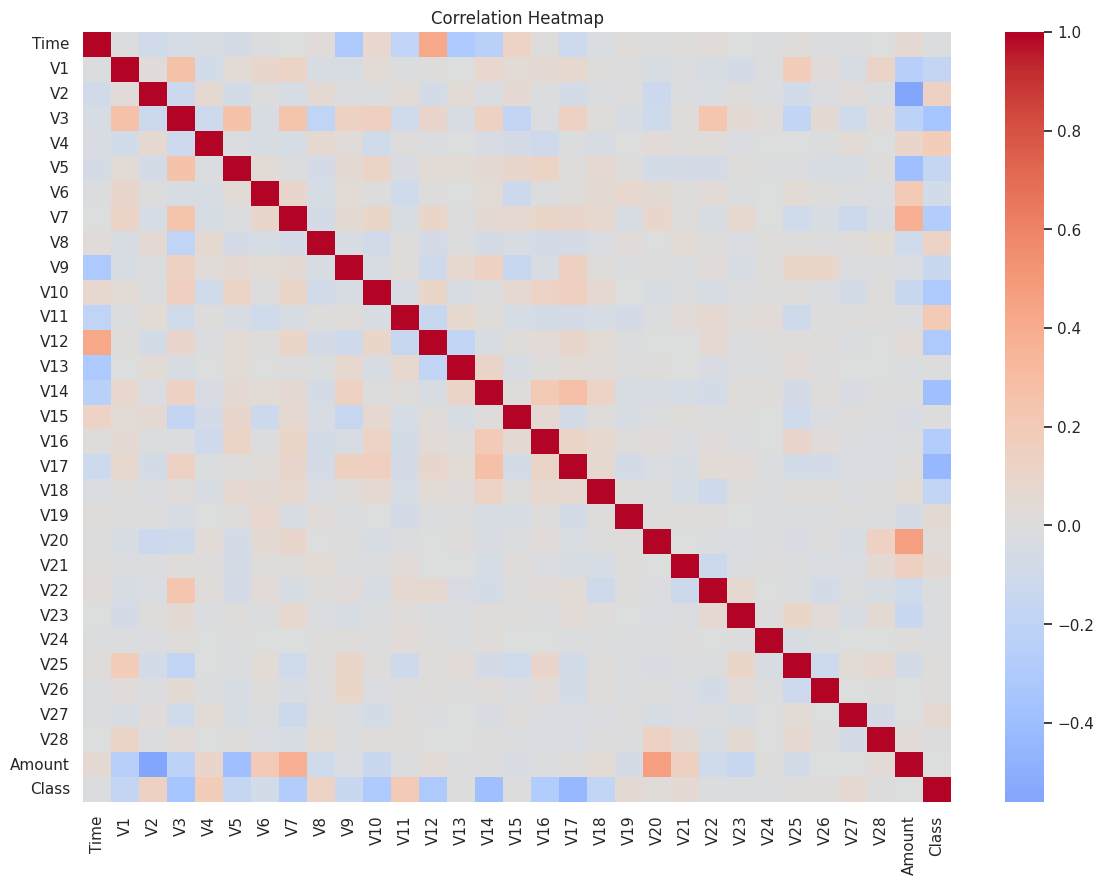

In [ ]:
# correlation heatmap (can be heavy but useful)
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

**There are no highly correlated columns (probably beacuase of PCA applied columns)**

In [ ]:
# correlation with target (top signals)
corr_target = df.corr(numeric_only=True)["Class"].sort_values(ascending=False)
corr_target.head(5), corr_target.tail(5)

(Class   1.000
 V11     0.205
 V4      0.184
 V2      0.146
 V8      0.131
 Name: Class, dtype: float64,
 V10   -0.304
 V12   -0.308
 V3    -0.343
 V14   -0.391
 V17   -0.438
 Name: Class, dtype: float64)

4. Data Preprocessing

In [ ]:
# Add log1p(Amount) for stability
df["Amount_log1p"] = np.log1p(df["Amount"])

In [ ]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class', 'Amount_log1p'],
      dtype='object')

In [ ]:
# separate features and target
X = df.drop(columns=["Class", "Amount"])   # removing AMount as we have Amount_log1p
y = df["Class"]

In [40]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

In [41]:
print("Dataset Shape:", X.shape)
print("Training Data Shape:", X_train.shape)
print("Test Data Shape:", X_test.shape)

Dataset Shape: (73376, 30)
Training Data Shape: (58700, 30)
Test Data Shape: (14676, 30)


In [38]:
# We will start with a Random Forest Classifier as a baseline
rf_clf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_clf.fit(X_train, y_train)

# Predictions
y_pred = rf_clf.predict(X_test)
y_pred_prob = rf_clf.predict_proba(X_test)[:, 1]

# Evaluation
print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"Average Precision Score: {average_precision_score(y_test, y_pred_prob):.4f}")

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     14640
         1.0       0.97      0.83      0.90        36

    accuracy                           1.00     14676
   macro avg       0.98      0.92      0.95     14676
weighted avg       1.00      1.00      1.00     14676

Average Precision Score: 0.8880


In [ ]:
print("Dataset Shape:", X.shape)
print("Training Data Shape:", X_train.shape)
print("Test Data Shape:", X_test.shape)

Dataset Shape: (73376, 30)
Training Data Shape: (58700, 30)
Test Data Shape: (14676, 30)


5. Model Building and Training

In [42]:
base_pipeline = Pipeline(
    [
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]
)

In [43]:
# train the model
base_pipeline.fit(X_train, y_train)

Pipeline(steps=[('model', DecisionTreeClassifier(random_state=42))])

In [44]:
y_base_train_pred = base_pipeline.predict(X_train)
y_base_test_pred = base_pipeline.predict(X_test)

In [45]:
base_train_acc = round(accuracy_score(y_train, y_base_train_pred)*100, 2)
base_test_acc = round(accuracy_score(y_test, y_base_test_pred)*100, 2)

In [46]:
print("Baseline Train Accuracy:", base_train_acc)
print("Baseline Test Accuracy:", base_test_acc)

Baseline Train Accuracy: 100.0
Baseline Test Accuracy: 99.9


In [47]:
print("Train - Classification Report")
print(classification_report(y_train, y_base_train_pred))

Train - Classification Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     58558
         1.0       1.00      1.00      1.00       142

    accuracy                           1.00     58700
   macro avg       1.00      1.00      1.00     58700
weighted avg       1.00      1.00      1.00     58700



In [48]:
print("Test - Classification Report")
print(classification_report(y_test, y_base_test_pred))

Test - Classification Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     14640
         1.0       0.84      0.75      0.79        36

    accuracy                           1.00     14676
   macro avg       0.92      0.87      0.90     14676
weighted avg       1.00      1.00      1.00     14676



Note: Accuracy score is not reliable because of class imbalance

In [49]:
# average precision score (or) pr-auc - training data
y_train_prob = base_pipeline.predict_proba(X_train)[:, 1]
print("Training Average Precision Score:", average_precision_score(y_train, y_train_prob))

Training Average Precision Score: 1.0


In [50]:
# average precision score (or) pr-auc - test data
y_test_prob = base_pipeline.predict_proba(X_test)[:, 1]
print("Test Average Precision Score:", average_precision_score(y_test, y_test_prob))

Test Average Precision Score: 0.6334257461161079


6. Model & optimization

In [51]:
k = 5
cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

In [52]:
models = {
    "dt_balanced": Pipeline(
        [
            ("model", DecisionTreeClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced"
            ))
        ]
    ),
    "hgb_balanced": Pipeline(
        [
            ("model", HistGradientBoostingClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced"
            ))
        ]
    ),
    "rf_balanced": Pipeline(
        [
            ("model", RandomForestClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced_subsample"
            ))
        ]
    )
}

In [53]:
for name, m in models.items():

    pr_auc_scores = []

    for tr_idx, te_idx, in cv.split(X_train, y_train):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]

        m.fit(X_tr, y_tr)
        pred_prob = m.predict_proba(X_te)[:, 1]

        pr_auc_scores.append(average_precision_score(y_te, pred_prob))

    print("Model name:", name)
    print("PR-AUC values:", pr_auc_scores)
    print("CV PR-AUC mean:", round(float(np.mean(pr_auc_scores)), 4))

# cross validation is a more reliable metric

Model name: dt_balanced
PR-AUC values: [np.float64(0.6063654828987027), np.float64(0.5108855126377638), np.float64(0.7443031556745356), np.float64(0.5437848792809729), np.float64(0.7360580782862401)]
CV PR-AUC mean: 0.6283
Model name: hgb_balanced
PR-AUC values: [np.float64(0.8426061390358883), np.float64(0.7824131597924947), np.float64(0.955008494602232), np.float64(0.7785084491431165), np.float64(0.8520335363020528)]
CV PR-AUC mean: 0.8421
Model name: rf_balanced
PR-AUC values: [np.float64(0.8660019250699341), np.float64(0.8237690788734219), np.float64(0.9672977624784853), np.float64(0.8492514188559324), np.float64(0.8552688283691989)]
CV PR-AUC mean: 0.8723


Best Model as per model selection process: Random Forest Classifier

Hyper parameter tuning for Random Forest Classifier



In [54]:
rfc_pipeline = Pipeline([
    ("model", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ))
])

In [57]:
param_dist = {
    'model__n_estimators': [100, 200, 300, 400, 500],
    'model__max_features': ['sqrt', 'log2'],
    'model__max_depth': [10, 20, 30, 40, 50, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__bootstrap': [True, False]
}

# random search
random_search = RandomizedSearchCV(
    estimator=rfc_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    scoring="average_precision",  # PR-AUC
    cv=cv,
    verbose=True
)

In [ ]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [ ]:
print("Best CV PR-AUC:", round(random_search.best_score_, 4))
print("Best params:", random_search.best_params_)

7. Re-train with best parameters

In [ ]:
best_rfc = Pipeline(
    [
        ("model", RandomForestClassifier(
            n_estimators=500,
            min_samples_leaf=1,
            max_features="log2",
            max_depth=30,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced_subsample"
        ))
    ]
)

In [ ]:
# train best rfc
best_rfc.fit(X_train, y_train)

In [ ]:
train_acc = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {round(train_acc*100, 2)} %")

In [ ]:
# confusion matrix
cm = confusion_matrix(y_train, y_train_pred)

plt.figure(figsize=(4,3))
# heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred non-fraud", "Pred fraud"],
    yticklabels=["Actual non-fraud", "Actual fraud"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [ ]:
print("Training Classification report")
print(classification_report(y_train, y_train_pred))

In [ ]:
train_proba = best_rfc.predict_proba(X_train)[:, 1]
print("Train PR-AUC:", round(average_precision_score(y_train, train_proba), 4))

In [ ]:
# test data prediction
y_test_pred = best_rfc.predict(X_test)

In [ ]:
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {round(test_acc*100, 2)} %")

In [ ]:
# confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(4,3))
# heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred non-fraud", "Pred fraud"],
    yticklabels=["Actual non-fraud", "Actual fraud"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [ ]:
print("Test Classification report")
print(classification_report(y_test, y_test_pred))

In [ ]:
test_proba = best_rfc.predict_proba(X_test)[:, 1]
print("Test PR-AUC:", round(average_precision_score(y_test, test_proba), 4))

9. Build a predictive system

In [ ]:
def predict_class(input_features):
    input_df = pd.DataFrame(
        [input_features],
        columns=X_train.columns
    )
    # get prediction from trained model
    prediction = best_rfc.predict(input_df)
    print("Model prediction:", prediction)
    if prediction[0] == 1:
        print("Fraud Transaction detected ❌")
    else:
        print("Non-Fraud Transaction ✅")

In [ ]:
X_test.head()

In [ ]:
y_test.head()

In [ ]:
y_test[y_test == 0].head()

In [ ]:
y_test[y_test == 1].head()

In [ ]:
test_1 = X_test.loc[263020].tolist()
print(test_1)

In [ ]:
predict_class(test_1)

In [ ]:
test_2 = X_test.loc[77348].tolist()
print(test_2)

In [ ]:
predict_class(test_2)